# EDA — Precio del mercado eléctrico español

Estacionalidad, outliers, huecos en los datos y correlaciones, antes de decidir qué features tienen sentido (Fase 4).

Este notebook asume que ya corriste `python -m scripts.ingest_historical` y que `data/electricidad.db` existe.

In [1]:
import sqlite3
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "..")  # para poder importar src.* al correr desde notebooks/

from src.features.load import load_catalog, load_wide_dataframe
from src.features.build import build_training_frame

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
conn = sqlite3.connect("../data/electricidad.db")
catalog = load_catalog("../data/esios_indicators_catalog.json")
df = load_wide_dataframe(conn, catalog)
print(df.shape)
print(df.index.min(), "->", df.index.max())
df.head()

(110255, 13)
2013-12-31 23:00:00+00:00 -> 2026-07-30 21:00:00+00:00


,precio_spot,pvpc,demanda_prevista,demanda_real,gen_eolica,gen_solar_fv,gen_solar_termica,gen_nuclear,gen_hidraulica,gen_ciclo_combinado,gen_carbon,prevision_eolica,prevision_fv
datetime_utc,,,,,,,,,,,,,
2013-12-31 23:00:00+00:00,20.02,NaN,143270.0,145810.0,66254.0,NaN,NaN,36506.0,2306.0,NaN,9228.0,NaN,NaN
2014-01-01 00:00:00+00:00,10.34,NaN,139932.0,140192.0,66900.0,NaN,NaN,36508.0,1927.0,NaN,7287.0,NaN,NaN
2014-01-01 01:00:00+00:00,5.35,NaN,130267.0,130035.0,65237.0,NaN,NaN,36521.0,-3008.0,NaN,4570.0,NaN,NaN
2014-01-01 02:00:00+00:00,5.00,NaN,121382.0,121152.0,64825.0,NaN,NaN,36506.0,-7219.0,NaN,4790.0,NaN,NaN
2014-01-01 03:00:00+00:00,0.50,NaN,115292.0,115324.0,63818.0,NaN,NaN,36469.0,-11067.0,NaN,3970.0,NaN,NaN


## 1. Huecos en los datos

`load_wide_dataframe` no rellena nada: un hueco real (NaN) significa que ese indicador no tenía dato para esa hora. Antes de nada, ¿cuántos huecos hay y dónde?

In [3]:
# huecos totales por columna (incluye el periodo previo a cobertura_desde, es esperado)
df.isna().sum().sort_values(ascending=False)

pvpc                   64991
gen_ciclo_combinado    44049
prevision_eolica       43824
prevision_fv           43824
gen_solar_fv           13122
gen_solar_termica      13122
gen_nuclear               20
demanda_real              20
gen_eolica                20
gen_hidraulica            20
gen_carbon                20
demanda_prevista          12
precio_spot                1
dtype: int64

In [4]:
# ¿el indice tiene huecos horarios (horas que faltan por completo, ninguna fuente las tiene)?
full_range = pd.date_range(df.index.min(), df.index.max(), freq="h", tz="UTC")
missing_hours = full_range.difference(df.index)
print(f"Horas totales esperadas: {len(full_range)}")
print(f"Horas presentes en el indice: {len(df.index)}")
print(f"Horas completamente ausentes: {len(missing_hours)}")
missing_hours[:20]

Horas totales esperadas: 110255
Horas presentes en el indice: 110255
Horas completamente ausentes: 0


DatetimeIndex([], dtype='datetime64[us, UTC]', freq='h')

In [5]:
# huecos de precio_spot (el target) DESPUES de su cobertura_desde -- estos si importan
precio_gaps = df[df["precio_spot"].isna()]
print(f"Huecos de precio_spot: {len(precio_gaps)}")
precio_gaps.index

Huecos de precio_spot: 1


DatetimeIndex(['2025-10-26 00:00:00+00:00'], dtype='datetime64[us, UTC]', name='datetime_utc', freq='h')

## 2. Outliers en el precio

El precio spot español puede ser 0 o negativo (exceso de renovables) y tener picos muy altos (escasez, precio del gas). Antes de asumir que un valor es un error, hay que verlo en contexto.

In [6]:
df["precio_spot"].describe()

count    110254.000000
mean         79.852247
std          84.760475
min         -39.300000
25%          39.280000
50%          54.150000
75%          89.400000
max        1020.630000
Name: precio_spot, dtype: float64

In [7]:
# valores negativos y valores extremos (percentil 99.9)
n_negativos = (df["precio_spot"] < 0).sum()
n_cero = (df["precio_spot"] == 0).sum()
p999 = df["precio_spot"].quantile(0.999)
print(f"Horas con precio negativo: {n_negativos}")
print(f"Horas con precio exactamente 0: {n_cero}")
print(f"Percentil 99.9: {p999:.1f} EUR/MWh")
df[df["precio_spot"] > p999][["precio_spot"]].sort_values("precio_spot", ascending=False).head(20)

Horas con precio negativo: 1487
Horas con precio exactamente 0: 1203
Percentil 99.9: 682.2 EUR/MWh


,precio_spot
datetime_utc,
2026-07-23 19:00:00+00:00,1020.63
2026-03-10 19:00:00+00:00,988.61
2026-07-22 19:00:00+00:00,976.40
2026-03-11 19:00:00+00:00,951.79
2026-07-27 19:00:00+00:00,929.09
2026-07-23 20:00:00+00:00,926.90
2026-07-22 20:00:00+00:00,923.15
2026-07-28 19:00:00+00:00,899.59
2026-03-10 20:00:00+00:00,882.10


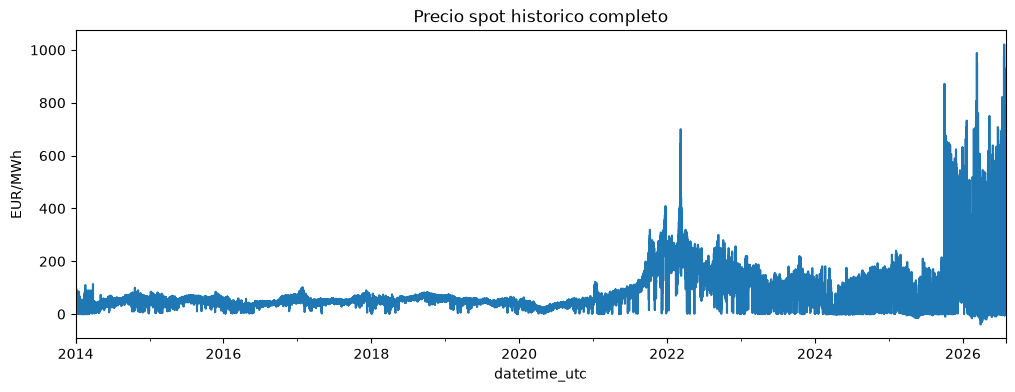

In [8]:
df["precio_spot"].plot(title="Precio spot historico completo")
plt.ylabel("EUR/MWh")
plt.show()

## 3. Estacionalidad

¿Cómo varia el precio por hora del día, dia de la semana y mes?

In [9]:
eda_df = df.copy()
idx_madrid = eda_df.index.tz_convert("Europe/Madrid")
eda_df["hour"] = idx_madrid.hour
eda_df["dayofweek"] = idx_madrid.dayofweek
eda_df["month"] = idx_madrid.month
eda_df["year"] = idx_madrid.year

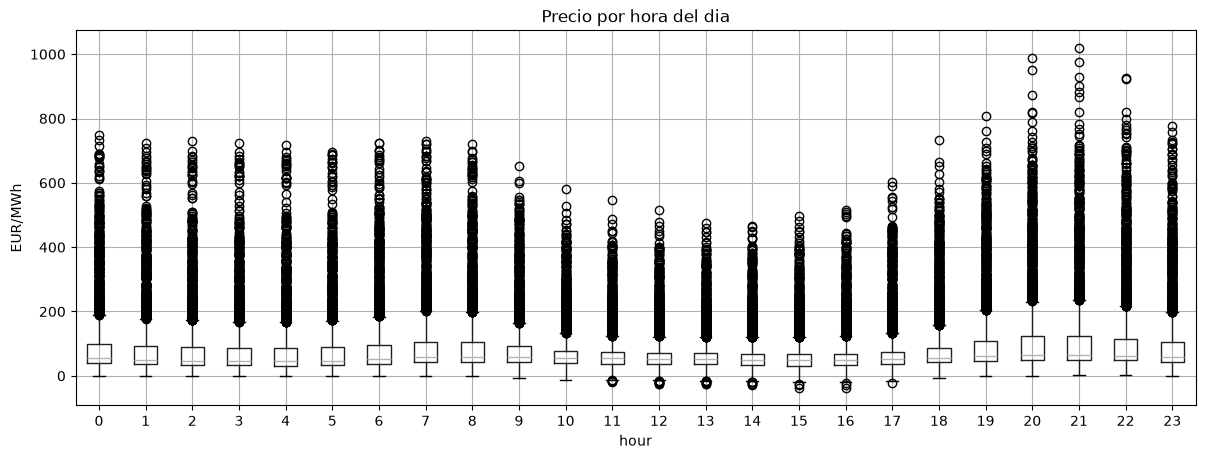

In [10]:
eda_df.boxplot(column="precio_spot", by="hour", figsize=(14, 5))
plt.title("Precio por hora del dia")
plt.suptitle("")
plt.ylabel("EUR/MWh")
plt.show()

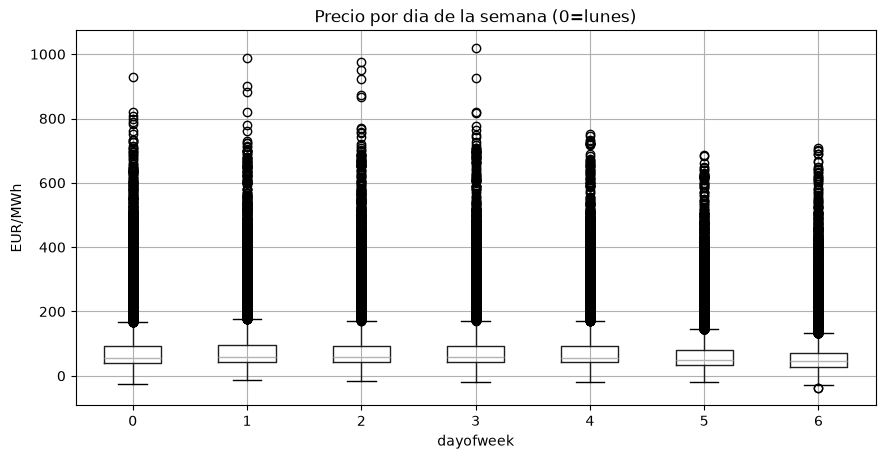

In [11]:
eda_df.boxplot(column="precio_spot", by="dayofweek", figsize=(10, 5))
plt.title("Precio por dia de la semana (0=lunes)")
plt.suptitle("")
plt.ylabel("EUR/MWh")
plt.show()

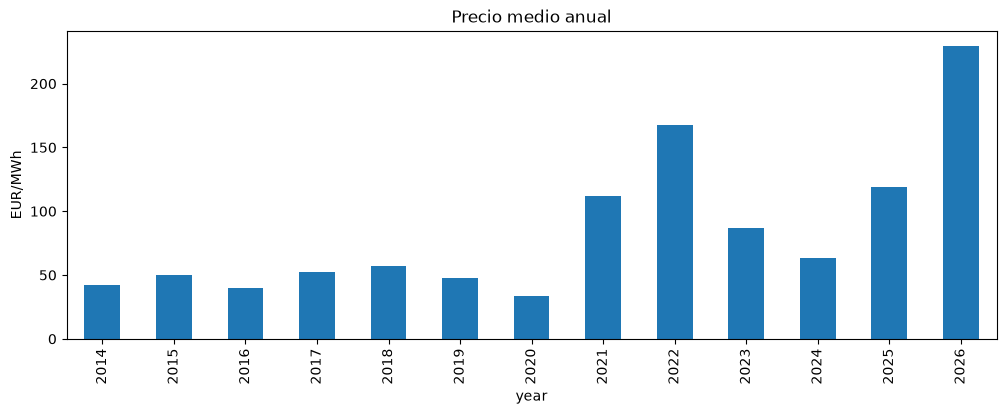

In [12]:
eda_df.groupby("year")["precio_spot"].mean().plot(kind="bar", title="Precio medio anual")
plt.ylabel("EUR/MWh")
plt.show()

## 4. Correlaciones

**Ojo**: esto es exploratorio, mira la relacion CONTEMPORANEA (misma hora) entre precio y el resto. Para el modelo real (Fase 5) los indicadores 'reales' (demanda_real, gen_*) solo se usan en lag, nunca en la misma hora que se predice — eso lo aplica `build_training_frame`. Aqui solo queremos entender la relacion, no construir el dataset de entrenamiento.

In [13]:
corr = df.corr(numeric_only=True)["precio_spot"].sort_values(ascending=False)
corr

precio_spot            1.000000
pvpc                   0.511543
gen_ciclo_combinado    0.406017
demanda_real           0.354002
demanda_prevista       0.353803
gen_hidraulica         0.336374
gen_nuclear            0.291814
gen_eolica             0.065416
gen_solar_fv          -0.046035
gen_solar_termica     -0.070265
prevision_eolica      -0.135659
prevision_fv          -0.150526
gen_carbon            -0.188566
Name: precio_spot, dtype: float64

## 5. Construir el dataset de features (leakage-safe) y comprobar cobertura

In [14]:
train = build_training_frame(df, catalog)
print("Shape completo (con NaNs por lags/cobertura):", train.shape)
print("Shape tras dropna (ventana usable para entrenar):", train.dropna().shape)
train.dropna().index.min(), train.dropna().index.max()

Shape completo (con NaNs por lags/cobertura): (110255, 55)
Shape tras dropna (ventana usable para entrenar): (62342, 55)


(Timestamp('2019-01-07 23:00:00+0000', tz='UTC'),
 Timestamp('2026-07-30 14:00:00+0000', tz='UTC'))

## Conclusiones

- **Huecos**: el indice horario esta completo (0 horas totalmente ausentes entre 2014-01-01 y hoy). Solo hay UN hueco real en precio_spot: 2025-10-26 00:00 UTC (coincide con el cambio de hora de invierno, ultimo domingo de octubre -- posible artefacto de esa transicion en la API de origen, a vigilar si se repite en otros anios). El resto de 'huecos' por columna son simplemente el periodo anterior a su cobertura_desde (esperado, no es un problema de calidad).
- **Outliers**: el precio spot va de -39.3 a 1020.6 EUR/MWh (media ~80, mediana ~54). Hay 1487 horas con precio negativo y 1203 horas en 0 -- consistente con exceso de renovables, NO son errores a limpiar. Los valores mas altos (por encima de 800 EUR/MWh) se concentran en 2025-10, 2026-03 y sobre todo 2026-07 -- volatilidad reciente a investigar antes de entrenar (¿evento puntual o cambio estructural?). Confirma la advertencia de la guia: usar MAE como metrica principal, MAPE se rompe con precios en 0.
- **Estacionalidad**: patrones claros por hora del dia y dia de la semana (ver boxplots) -- justifica las features de calendario y los lags de 24h/168h.
- **Correlaciones contemporaneas mas fuertes con el precio**: pvpc (0.51, logico, se deriva del spot), gen_ciclo_combinado (0.41, el gas suele marcar el precio marginal), demanda_real/prevista (~0.35), gen_hidraulica (0.34), gen_nuclear (0.29). Eolica/solar cerca de 0 o negativas (~-0.05 a -0.19) -- ojo, correlacion contemporanea no implica causalidad ni es utilizable tal cual como feature (ver build_training_frame, que solo usa estos indicadores en lag).
- **Decision pendiente para la Fase 5**: incluir pvpc como feature limita la ventana de entrenamiento utilizable (tras dropna) a 2021-06-07 -> hoy (~42.400 filas, 5 años), porque su cobertura empieza en 2021-06 y el lag de 168h la retrasa una semana mas. Sin pvpc, se podria entrenar con el historico completo desde 2014 (~110.000 filas, 12.5 anios). Hay que decidir conscientemente ese trade-off (mas historia vs. una feature con buena correlacion) antes de construir el modelo.


## 6. Regimen regulatorio: ¿tope al gas?

El salto de error del baseline desde 2021 (ver seccion de correlaciones/conclusiones) ¿es volatilidad organica del mercado, o coincide con un cambio de regimen regulatorio real?

El mecanismo iberico de ajuste ('tope al gas', RD-ley 10/2022) limito el precio del gas usado para fijar el marginalista entre **2022-06-15** y **2023-12-31**. Marcamos 3 periodos (fechas en calendario de Europe/Madrid):
- **normal**: 2014-01 -> 2022-06-14
- **tope_gas**: 2022-06-15 -> 2023-12-31
- **post_tope**: 2024-01-01 -> hoy

In [15]:
from src.model.baseline import naive_forecast
from src.model.evaluate import evaluate_by_regime, train_test_split_by_date
from src.model.regimes import assign_regime

y_pred_naive = naive_forecast(df, lag_hours=24)
regime_table = evaluate_by_regime(df["precio_spot"], y_pred_naive)
regime_table

,regimen,media,std,mae,rmse,n
0,normal,62.803639,52.932734,8.670674,16.335056,74063
1,tope_gas,102.642350,47.832917,22.521672,32.388835,13561
2,post_tope,122.054478,146.424003,36.238850,65.550154,22605
3,total,79.852247,84.760475,16.028194,34.489234,110229


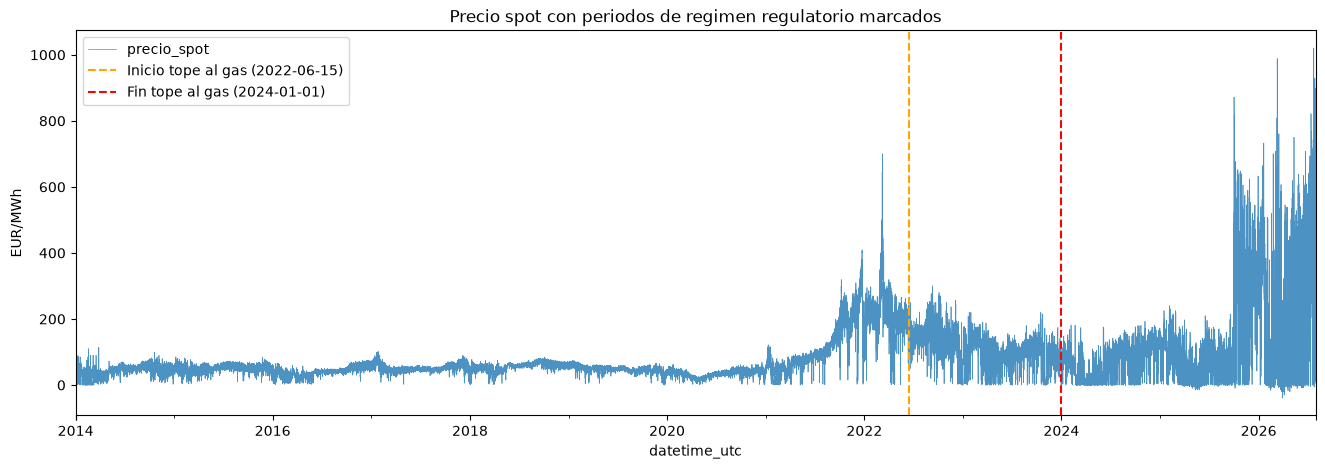

In [16]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 5))
df["precio_spot"].plot(ax=ax, linewidth=0.5, alpha=0.8)

tope_gas_inicio = pd.Timestamp("2022-06-15", tz="Europe/Madrid")
post_tope_inicio = pd.Timestamp("2024-01-01", tz="Europe/Madrid")

ax.axvline(tope_gas_inicio, color="orange", linestyle="--", label="Inicio tope al gas (2022-06-15)")
ax.axvline(post_tope_inicio, color="red", linestyle="--", label="Fin tope al gas (2024-01-01)")
ax.set_title("Precio spot con periodos de regimen regulatorio marcados")
ax.set_ylabel("EUR/MWh")
ax.legend()
plt.show()

In [17]:
# composicion de regimenes del holdout usado en scripts/train_baseline.py (ultimos ~12 meses)
_, test = train_test_split_by_date(df, "2025-08-01T00:00")
regime_test = assign_regime(test.index)
regime_test.value_counts()

post_tope    8734
normal          0
tope_gas        0
Name: count, dtype: int64

### Conclusion del analisis de regimen

Numeros reales (baseline naive, precio de ayer a la misma hora):

| regimen   | media EUR/MWh | std EUR/MWh | MAE  | RMSE | n horas |
|-----------|--------------:|------------:|-----:|-----:|--------:|
| normal    | 62.80         | 52.93       | 8.67 | 16.34| 74,063  |
| tope_gas  | 102.64        | 47.83       | 22.52| 32.39| 13,561  |
| post_tope | 122.05        | 146.42      | 36.24| 65.55| 22,605  |

- **SI hay una discontinuidad real, no es solo volatilidad acumulada**: la std en 'post_tope' (146.4) es ~2.8x la de 'normal' (52.9) y ~3x la de 'tope_gas' (47.8) -- el fin del tope al gas coincide con un salto claro de nivel Y de dispersion, visible tambien en la grafica (la serie se dispara y se vuelve mucho mas errática justo despues de la linea roja, 2024-01-01).
- **El holdout de  (ultimos ~12 meses) cae al 100% dentro de 'post_tope'** (8,734 de 8,734 horas). El MAE de 63.93 EUR/MWh del holdout NO es una mezcla de regimenes -- es directamente el nivel de error de 'mercado sin tope', el mas dificil de los tres, y ademas sigue escalando dentro del propio post_tope (MAE anual: 18.3 en 2024, 36.6 en 2025, 66.8 en 2026 -- ver seccion de conclusiones generales). Es decir: no es un salto discreto y ya esta, sino un regimen que ademas de mas volatil parece seguir empeorando año a año.
- **Implicacion para LightGBM**: evaluar con una sola metrica agregada 2014-hoy (o incluso solo el holdout reciente) puede ser enganoso -- reportar SIEMPRE el MAE por regimen ademas del holdout global. Vale la pena valorar (a decidir antes de entrenar): (a) una feature dummy de regimen ('tope_gas_activo'/'post_tope'), (b) entrenar/evaluar por separado en post_tope ya que es el regimen actual y el mas relevante para produccion, o (c) ambas cosas.